In [6]:
from google.colab import files

In [7]:
uploaded=files.upload()

Saving Diabetes Health Indicators.csv to Diabetes Health Indicators.csv


In [8]:
import numpy as np
import pandas as pd

In [26]:
df=pd.read_csv("/content/Diabetes Health Indicators.csv")

In [27]:
print(df.columns.tolist())

['DIABETE4', 'DIABTYPE', '_RFHYPE6', '_RFCHOL3', '_CHOLCH3', '_BMI5', 'SMOKE100', 'CVDSTRK3', '_MICHD', 'EXERANY2', 'PRIMINS1', 'MEDCOST1', 'GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'DIFFWALK', '_SEX', '_AGEG5YR', '_EDUCAG', '_INCOMG1']


In [28]:
!pip install xgboost catboost imbalanced-learn shap lime -q

In [29]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [30]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 433323
Columns : 20


In [31]:
df

,DIABETE4,DIABTYPE,_RFHYPE6,_RFCHOL3,_CHOLCH3,_BMI5,SMOKE100,CVDSTRK3,_MICHD,EXERANY2,PRIMINS1,MEDCOST1,GENHLTH,MENTHLTH,PHYSHLTH,DIFFWALK,_SEX,_AGEG5YR,_EDUCAG,_INCOMG1
0,1.0,NaN,2,1.0,1,3047.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,88.0,88.0,1.0,2,13,3,9
1,3.0,NaN,2,2.0,1,2856.0,2.0,2.0,2.0,1.0,3.0,2.0,2.0,88.0,88.0,2.0,2,13,3,9
2,3.0,NaN,2,2.0,1,2231.0,1.0,2.0,2.0,1.0,3.0,1.0,4.0,2.0,6.0,1.0,2,13,2,1
3,3.0,NaN,1,1.0,1,2744.0,2.0,2.0,2.0,1.0,3.0,2.0,2.0,88.0,2.0,1.0,2,12,3,9
4,1.0,NaN,2,1.0,1,2585.0,2.0,2.0,2.0,1.0,3.0,2.0,4.0,88.0,88.0,1.0,2,12,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433318,3.0,NaN,2,2.0,1,2921.0,2.0,7.0,2.0,1.0,77.0,2.0,3.0,30.0,12.0,2.0,1,10,3,3
433319,3.0,NaN,1,1.0,1,2496.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,88.0,88.0,2.0,2,3,4,4
433320,3.0,NaN,1,2.0,1,3438.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,88.0,10.0,2.0,2,7,4,6
433321,1.0,2.0,2,2.0,1,2386.0,2.0,2.0,2.0,1.0,3.0,2.0,3.0,88.0,88.0,2.0,2,10,4,2


In [32]:
df.isnull().sum()

,0
DIABETE4,5
DIABTYPE,409048
_RFHYPE6,0
_RFCHOL3,51811
_CHOLCH3,0
_BMI5,40535
SMOKE100,19674
CVDSTRK3,4
_MICHD,4585
EXERANY2,2


In [33]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 6638


In [34]:
df = df.drop_duplicates()

In [35]:
df["DIABETE4"].value_counts()

,count
DIABETE4,
3.0,352184
1.0,59684
4.0,10592
2.0,3249
7.0,683
9.0,288


In [36]:
df = df[df["DIABETE4"].isin([1,2,3])]

In [37]:
df.reset_index(drop=True,inplace=True)

In [38]:
df.drop("DIABTYPE",axis=1,inplace=True)

In [39]:
df["BMI"] = df["_BMI5"]/100

In [40]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    else:
        return 3
df["BMI_Category"] = df["BMI"].apply(bmi_category)

In [41]:
df["HealthScore"] = (df["GENHLTH"] +df["MENTHLTH"] +df["PHYSHLTH"])

In [42]:
df["LifestyleScore"] = (df["SMOKE100"] +df["EXERANY2"])

In [43]:
df["RiskScore"] = (df["_RFHYPE6"] +df["_RFCHOL3"] +df["CVDSTRK3"] +df["_MICHD"] +df["BMI"])

In [44]:
df

,DIABETE4,_RFHYPE6,_RFCHOL3,_CHOLCH3,_BMI5,SMOKE100,CVDSTRK3,_MICHD,EXERANY2,PRIMINS1,...,DIFFWALK,_SEX,_AGEG5YR,_EDUCAG,_INCOMG1,BMI,BMI_Category,HealthScore,LifestyleScore,RiskScore
0,1.0,2,1.0,1,3047.0,2.0,2.0,2.0,2.0,3.0,...,1.0,2,13,3,9,30.47,3,178.0,4.0,37.47
1,3.0,2,2.0,1,2856.0,2.0,2.0,2.0,1.0,3.0,...,2.0,2,13,3,9,28.56,2,178.0,3.0,36.56
2,3.0,2,2.0,1,2231.0,1.0,2.0,2.0,1.0,3.0,...,1.0,2,13,2,1,22.31,1,12.0,2.0,30.31
3,3.0,1,1.0,1,2744.0,2.0,2.0,2.0,1.0,3.0,...,1.0,2,12,3,9,27.44,2,92.0,3.0,33.44
4,1.0,2,1.0,1,2585.0,2.0,2.0,2.0,1.0,3.0,...,1.0,2,12,3,5,25.85,2,180.0,3.0,32.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415112,3.0,2,2.0,1,2921.0,2.0,7.0,2.0,1.0,77.0,...,2.0,1,10,3,3,29.21,2,45.0,3.0,42.21
415113,3.0,1,1.0,1,2496.0,2.0,2.0,2.0,2.0,1.0,...,2.0,2,3,4,4,24.96,1,178.0,4.0,30.96
415114,3.0,1,2.0,1,3438.0,2.0,2.0,2.0,1.0,1.0,...,2.0,2,7,4,6,34.38,3,100.0,3.0,41.38
415115,1.0,2,2.0,1,2386.0,2.0,2.0,2.0,1.0,3.0,...,2.0,2,10,4,2,23.86,1,179.0,3.0,31.86


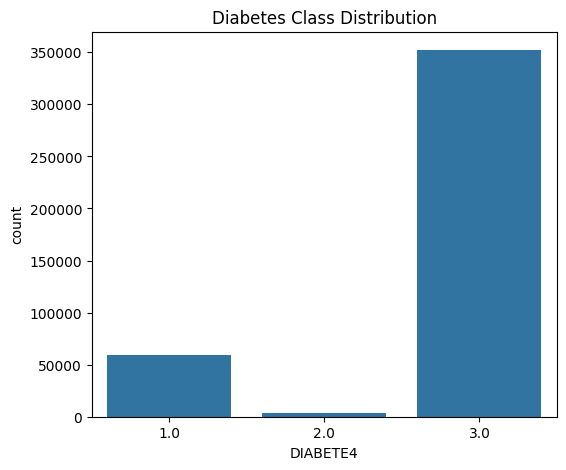

In [45]:
plt.figure(figsize=(6,5))
sns.countplot(x="DIABETE4",data=df)
plt.title("Diabetes Class Distribution")
plt.show()

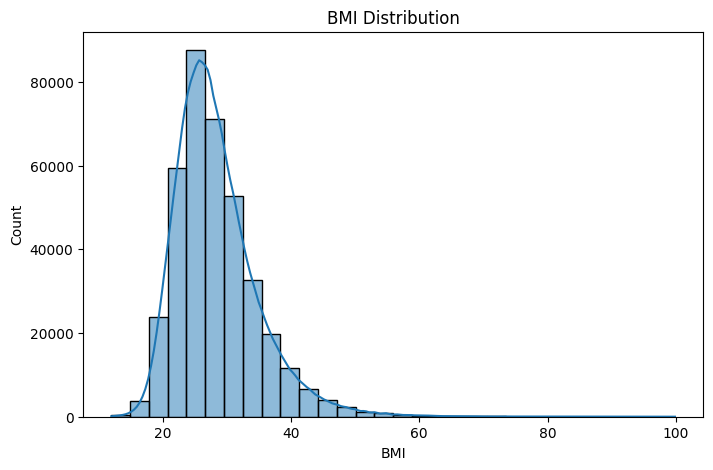

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df["BMI"],bins=30,kde=True)
plt.title("BMI Distribution")
plt.show()

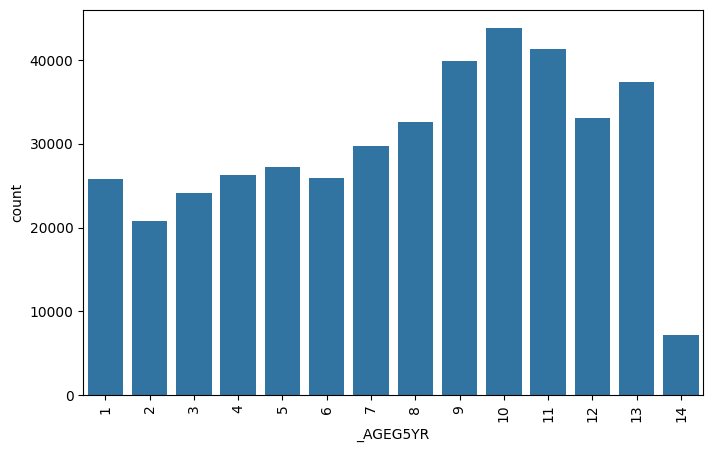

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(x="_AGEG5YR",data=df)
plt.xticks(rotation=90)
plt.show()

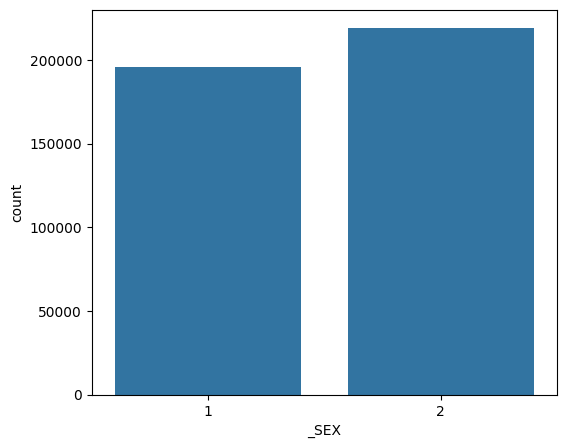

In [48]:
plt.figure(figsize=(6,5))
sns.countplot(x="_SEX",data=df)
plt.show()

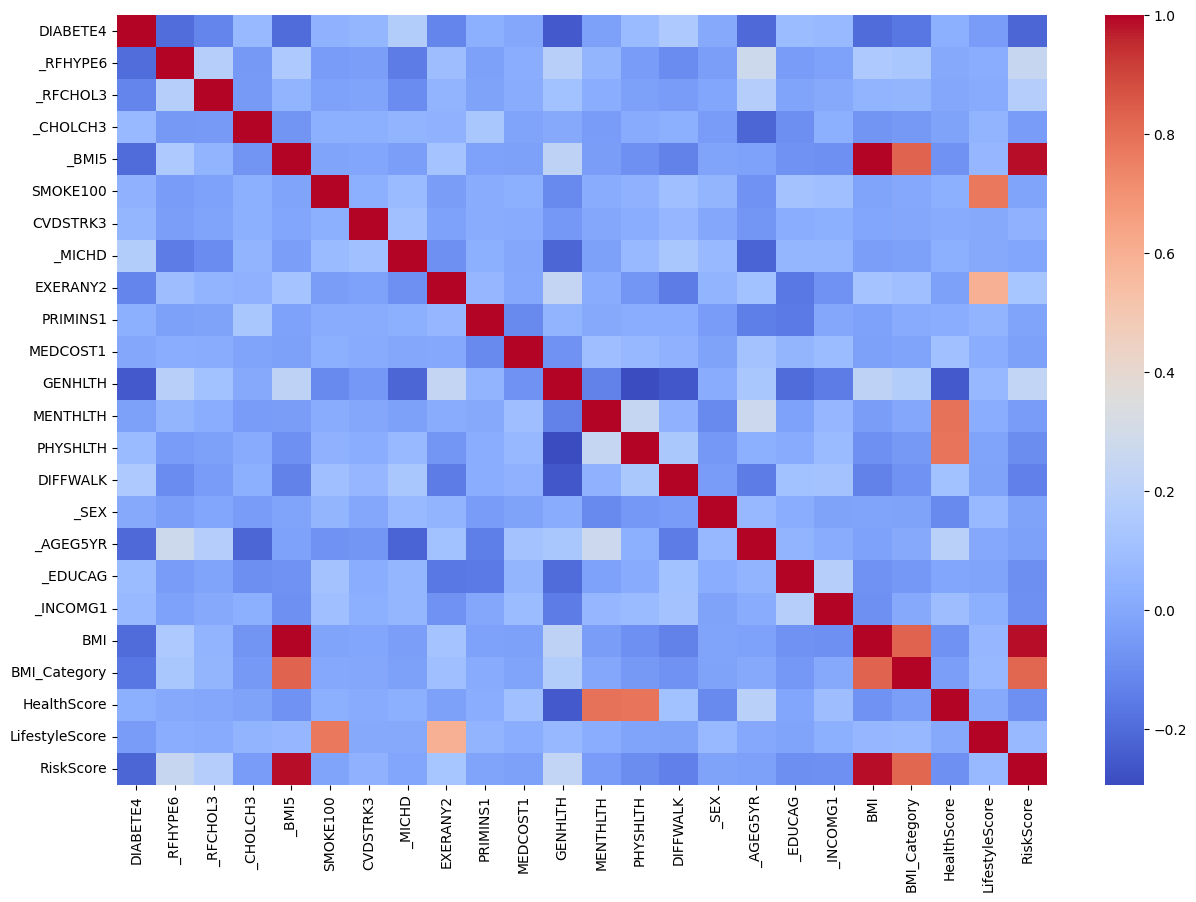

In [49]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

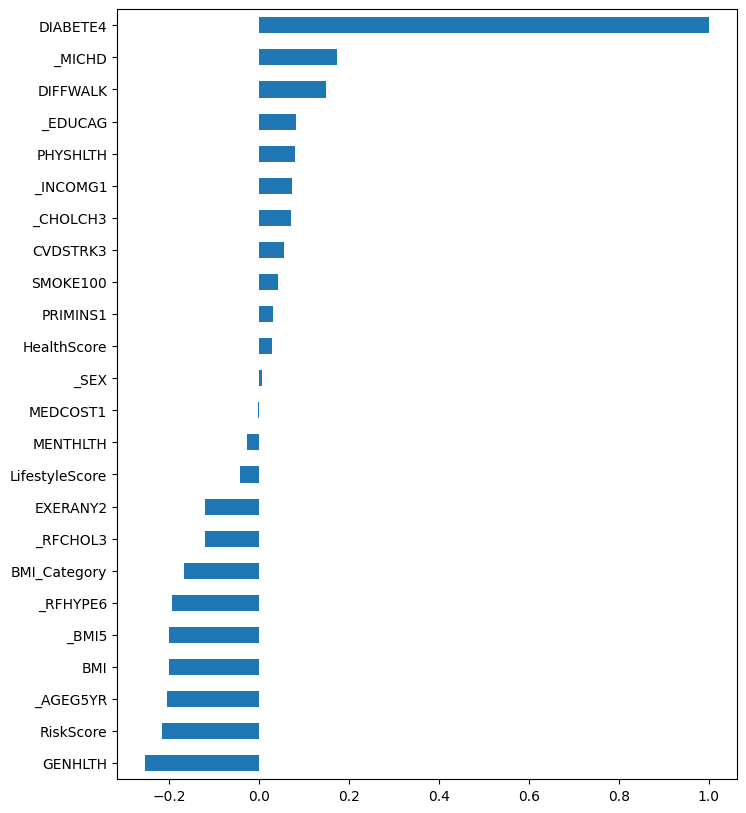

In [50]:
corr = df.corr()["DIABETE4"].sort_values()
plt.figure(figsize=(8,10))
corr.plot(kind="barh")
plt.show()

In [51]:
df.to_csv("Clean_Diabetes.csv",index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully


In [52]:
print(df.shape)
df.head()

(415117, 24)


,DIABETE4,_RFHYPE6,_RFCHOL3,_CHOLCH3,_BMI5,SMOKE100,CVDSTRK3,_MICHD,EXERANY2,PRIMINS1,...,DIFFWALK,_SEX,_AGEG5YR,_EDUCAG,_INCOMG1,BMI,BMI_Category,HealthScore,LifestyleScore,RiskScore
0,1.0,2,1.0,1,3047.0,2.0,2.0,2.0,2.0,3.0,...,1.0,2,13,3,9,30.47,3,178.0,4.0,37.47
1,3.0,2,2.0,1,2856.0,2.0,2.0,2.0,1.0,3.0,...,2.0,2,13,3,9,28.56,2,178.0,3.0,36.56
2,3.0,2,2.0,1,2231.0,1.0,2.0,2.0,1.0,3.0,...,1.0,2,13,2,1,22.31,1,12.0,2.0,30.31
3,3.0,1,1.0,1,2744.0,2.0,2.0,2.0,1.0,3.0,...,1.0,2,12,3,9,27.44,2,92.0,3.0,33.44
4,1.0,2,1.0,1,2585.0,2.0,2.0,2.0,1.0,3.0,...,1.0,2,12,3,5,25.85,2,180.0,3.0,32.85


In [53]:
from google.colab import files
upload=files.download("Clean_Diabetes.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>